In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

##Interpretation

This cell imports the required Python libraries for analyzing the logistics dataset and identifying meaningful business insights based on shipment performance and operational factors.

In [2]:
df = pd.read_csv('/content/drive/MyDrive/DATA SET /cleaned_merged_dataset_v3.csv')

df.head()

,shipment_id,booking_id,customer_id,product_id,carrier_id,warehouse_id,route_id,vehicle_id,customs_id,weather_id,booking_date,ship_date,expected_delivery_date,shipping_mode,shipment_type,priority,weight_kg,volume_cbm,declared_value,insurance,fragile_x,carrier_name,carrier_type,average_rating,fleet_size,years_of_service,headquarters,customer_name,customer_type,industry,city_x,state_x,country,registration_date,customer_status,customs_required,documentation_complete,inspection_required,cargo_type,destination_country_x,product_name,category,hs_code,hazardous,perishable,temperature_controlled,fragile_y,weight_per_unit,supplier_name,origin_city,destination_city,origin_country,destination_country_y,origin_port,destination_port,distance_km,average_transit_days,route_risk,traffic_index,history_id,actual_delivery_date,delivery_status,delivery_attempts,vehicle_number,vehicle_type,capacity_kg,fuel_type,maintenance_status,vehicle_age,warehouse_name,city_y,state_y,warehouse_capacity,current_utilization,warehouse_type,city,forecast_date,weather_condition,temperature,rainfall,humidity,wind_speed,visibility
0,2fbc2ba7-78db-4cd4-abc4-8484f8e296c0,BK100000,9d07a288-d20c-4632-be32-a80646174f82,7d9bcdf2-1cf5-4fdd-ba64-30b5ab5770fe,1b55fff6-046a-4456-9cb0-b8cd21addf5a,c8447ce1-fe0b-4d5b-96c9-b9a275ad8a25,aa747821-06b3-495f-b000-1b2e8b911707,f5ca04c7-97ce-4489-bfc9-69bb578f9273,de1b0e23-43fb-4d0d-a84a-07337bbc6411,a79111db-721a-4600-b313-ae9ab7f6f924,2023-08-12,2023-08-13,2023-09-12,Sea,Import,Standard,40.6,0.12,8237.48,False,False,"Jones, Scott and Rodriguez Logistics",Air,2.94,437.0,30,Karachi,Gibson Ltd,Business,E-commerce,Toronto,Ontario,Canada,2023-12-04,Active,False,True,False,Textiles,India,Project Machinery,Machinery,2120.77,False,False,False,False,9.24,Martin-Taylor,New York,Dubai,USA,UAE,Port of New York,Port of Dubai,7116.7,30,Low,50.0,d945d0ad-965e-4f75-a076-ad3e6df04011,2023-09-15,Delivered,2.0,WW-2798-KQ,Ship,23673,Diesel,Under Maintenance,8,Mumbai Regional Hub,Mumbai,Maharashtra,18128.0,89.9,Regional,Sao Paulo,2025-08-09,Rain,27.9,0.1,36.4,5.3,9.5
1,1881d036-771b-4eb6-ae7a-ac78f41dfd79,BK100001,189fab37-8b05-4e69-b000-be0f6ec9dbc4,5d909ac1-2fad-4861-a19e-79e99e125dfe,2a4ec8f6-16fe-4936-ac67-37fc52238e51,632799e1-4e31-4ba3-838e-c12663328395,1a5d3872-1ddf-4ff8-93e7-07fc5acafc25,830c2f7a-afba-4df9-b8b9-b5e5e1489cee,1d81cb99-8755-4f4a-bc2e-1bb414bbbe42,db916c48-9524-4904-b0d0-6016baeb0a3c,2024-06-16,2024-06-17,2024-06-22,Rail,Export,Standard,57.1,0.22,7133.89,True,False,Gray Ltd Cargo,Rail,4.25,81.0,36,Chennai,Cook-Hines,Business,E-commerce,Hong Kong,Hong Kong,China,2022-10-01,Active,True,False,False,Toys,India,Case Food & Beverage,Food & Beverage,7089.43,False,False,True,True,11.65,Colon LLC,Cape Town,Los Angeles,South Africa,USA,Port of Cape Town,Port of Los Angeles,3265.9,5,High,87.0,1efbf0f3-db41-447b-bc9f-da1197fe9b73,2024-06-23,Delivered,1.0,VM-2181-NE,Ship,12342,Diesel,Due,6,Melbourne Distribution Center,Melbourne,Victoria,4504.0,88.5,Regional,Delhi,2026-07-14,Cloudy,31.2,0.0,51.9,1.5,7.0
2,db4bcd2c-d981-4b8a-b61c-83c6dae109d8,BK100002,32320649-068b-4887-b776-ab2d9941cb1a,b1eb6a65-e462-4da5-a91f-78d00b0c241f,22c1d43a-dc69-48e3-8df1-18788f0cc19a,931ea697-c860-4af1-a6c8-e86f72c220ba,ddfeb7c4-87b1-4916-b523-22df1f1c16f3,a33fbf71-6b09-4246-921e-dd0de3c4600f,7e7b4406-6108-4603-897f-0f852c9f8927,6afe8d32-c11d-453f-9ca2-482ccc2e029d,2023-11-25,2023-11-27,2023-11-28,Sea,Export,Standard,19.3,0.06,1813.83,False,True,"Foster, Garcia and Turner Shipping",Air,3.59,317.0,25,Jakarta,"Browning, Jones and Miller",Business,Pharma,Dubai,Dubai,UAE,2024-02-13,Active,True,True,False,Pharmaceuticals,China,Through Toy,Toys,7126.17,False,False,False,False,5.79,"Gutierrez, Huang and Ellis",Bengaluru,Ho Chi Minh City,India,Vietnam,Port of Bengaluru,Port of Ho Chi Minh City,2817.4,1,Low,21.0,2a991dc6-0cc1-4b90-8ee7-32014f1a8572,2023-11-28,Delivered,1.0,PV-8944-IZ,Truck,34040,CNG,Good,10,Istanbul Fulfillment Center,Istanbul,Istanbul,15182.0,69.0,Distribution,A

##Interpretation

This cell loads the cleaned logistics dataset into a DataFrame. It verifies that the dataset is ready for extracting business insights and identifying factors affecting shipment delays.

In [3]:
# Convert date columns

df['expected_delivery_date'] = pd.to_datetime(df['expected_delivery_date'])
df['actual_delivery_date'] = pd.to_datetime(df['actual_delivery_date'])

# Shipment Delay

df['shipment_delay'] = (
    df['actual_delivery_date'] -
    df['expected_delivery_date']
).dt.days

# Delay Days

df['delay_days'] = df['shipment_delay'].clip(lower=0)

# Binary Target

df['shipment_delayed'] = (
    df['shipment_delay'] > 0
).astype(int)

##Interpretation

This cell first calculates the shipment delay by finding the difference, in days, between the actual delivery date and the expected delivery date. It then creates a new binary target variable named shipment_delayed, where a value of 1 represents delayed shipments and 0 represents shipments delivered on time or earlier. This target variable simplifies the analysis of delivery performance and serves as the dependent variable for future machine learning classification models aimed at predicting shipment delays.

In [4]:
# Numerical columns only
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove unnecessary columns
for col in ['shipment_delay', 'shipment_delayed']:
    if col in numerical_cols:
        numerical_cols.remove(col)

# Correlation with Delay Days
corr = df[numerical_cols].corr()['delay_days'].sort_values(ascending=False)

print(corr)

delay_days              1.000000
delivery_attempts       0.401157
traffic_index           0.072611
current_utilization     0.044389
weight_kg               0.036390
fleet_size              0.033019
volume_cbm              0.030622
humidity                0.029982
years_of_service        0.020025
wind_speed              0.018782
declared_value          0.017544
weight_per_unit         0.016400
temperature             0.015852
capacity_kg             0.015788
rainfall                0.004224
vehicle_age             0.002133
hs_code                -0.009438
distance_km            -0.013016
warehouse_capacity     -0.016164
average_transit_days   -0.025477
average_rating         -0.079769
visibility             -0.099404
Name: delay_days, dtype: float64


##Interpretation

This cell analyzes the correlation between shipment delay and all numerical variables in the dataset. The correlation values help identify which features have the strongest positive or negative relationship with delivery delays. Variables with relatively higher correlation values, such as delivery attempts, distance, and traffic index, may have a greater influence on shipment delays and can be considered important features for predictive modeling. Overall, the weak correlation values indicate that shipment delays are affected by multiple operational and environmental factors rather than a single numerical variable.

In [5]:
df[['carrier_id', 'carrier_name']].head(10)

,carrier_id,carrier_name
0,1b55fff6-046a-4456-9cb0-b8cd21addf5a,"Jones, Scott and Rodriguez Logistics"
1,2a4ec8f6-16fe-4936-ac67-37fc52238e51,Gray Ltd Cargo
2,22c1d43a-dc69-48e3-8df1-18788f0cc19a,"Foster, Garcia and Turner Shipping"
3,28d939e1-9282-48ee-9a14-a7290d7e0350,Rivera Inc Shipping
4,75eda72c-e34b-40aa-b112-e56562058a14,"Thomas, Vaughan and Copeland Cargo"
5,3ee36a0b-8b6e-4319-9a46-7e2a1a3c5c9f,Weaver-Thompson Logistics
6,33cf5931-ba67-4b99-9de6-685589a6646f,"Walker, Cunningham and Zuniga Freight"
7,aabfdc24-e492-4483-a2cc-ca4e47359860,"Santiago, Daniel and Rogers Logistics"
8,c778e652-6e62-48d0-8ab5-4fb8a8b7ca14,"Stewart, Mann and Hoffman Cargo"
9,35b0a64d-f591-47e2-91a1-30adb2e1f912,"Fry, Myers and Gamble Freight"


In [6]:
print(df['carrier_name'].unique())

['Jones, Scott and Rodriguez Logistics' 'Gray Ltd Cargo'
 'Foster, Garcia and Turner Shipping' 'Rivera Inc Shipping'
 'Thomas, Vaughan and Copeland Cargo' 'Weaver-Thompson Logistics'
 'Walker, Cunningham and Zuniga Freight'
 'Santiago, Daniel and Rogers Logistics' 'Stewart, Mann and Hoffman Cargo'
 'Fry, Myers and Gamble Freight' 'Reed LLC Logistics'
 'Buchanan, Walker and Chapman Cargo'
 'Harris, Anderson and Love Logistics'
 'Johnson, Guzman and Mccall Freight'
 'Bradford, Salinas and Kelly Freight' 'Yu-Brooks Logistics'
 'Thompson PLC Logistics' 'Robinson, Fox and Smith Logistics'
 'Stark, Schroeder and Mathis Logistics' 'Gallagher and Sons Logistics'
 'Johnson, Haynes and Meza Freight'
 'Phillips, Thompson and Smith Logistics' 'Conner-Yu Shipping'
 'Fields Inc Shipping' 'Davis and Sons Cargo' 'Brown-Hernandez Shipping'
 'Baker and Sons Freight' 'Adams Ltd Freight' 'Drake-Wolfe Cargo'
 'Daugherty Ltd Logistics']


carrier_name
Buchanan, Walker and Chapman Cargo        2.773973
Jones, Scott and Rodriguez Logistics      2.683453
Baker and Sons Freight                    2.636364
Weaver-Thompson Logistics                 2.324561
Foster, Garcia and Turner Shipping        2.255814
Bradford, Salinas and Kelly Freight       2.050420
Daugherty Ltd Logistics                   1.975410
Reed LLC Logistics                        1.947368
Yu-Brooks Logistics                       1.919708
Robinson, Fox and Smith Logistics         1.896825
Walker, Cunningham and Zuniga Freight     1.731884
Davis and Sons Cargo                      1.710744
Brown-Hernandez Shipping                  1.671533
Gallagher and Sons Logistics              1.536000
Fields Inc Shipping                       1.516129
Fry, Myers and Gamble Freight             1.515924
Conner-Yu Shipping                        1.507576
Johnson, Guzman and Mccall Freight        1.507463
Thomas, Vaughan and Copeland Cargo        1.458015
Harris, Anderson a

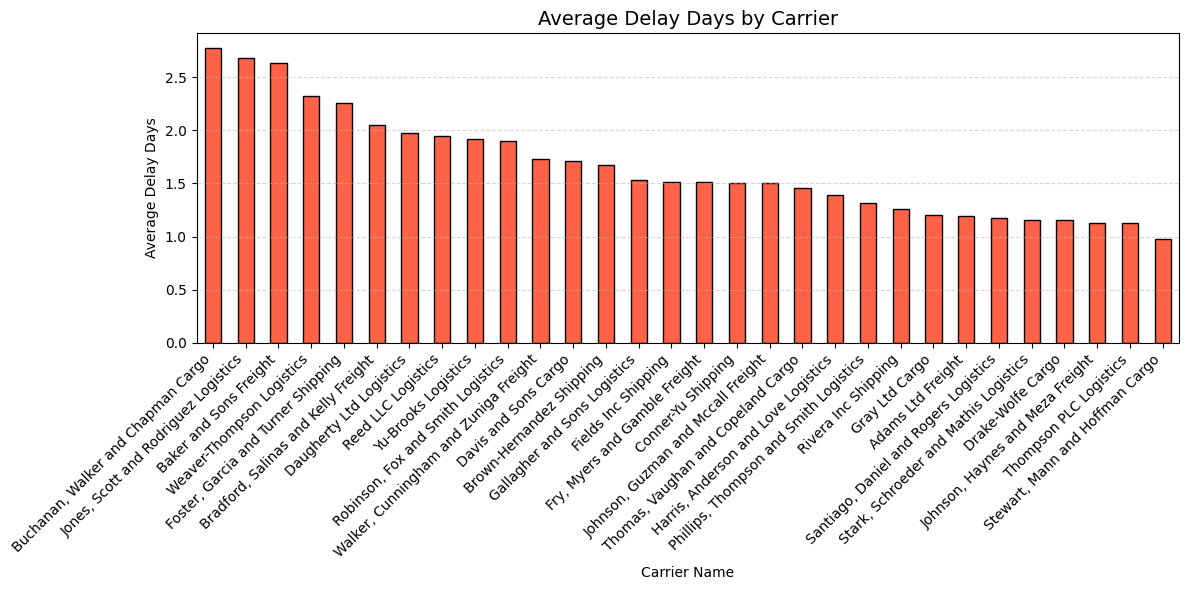

In [7]:
carrier_delay = (
    df.groupby('carrier_name')['delay_days']
      .mean()
      .sort_values(ascending=False)
)

print(carrier_delay)

plt.figure(figsize=(12,6))

carrier_delay.plot(
    kind='bar',
    color='tomato',
    edgecolor='black'
)

plt.title("Average Delay Days by Carrier", fontsize=14)

plt.xlabel("Carrier Name")

plt.ylabel("Average Delay Days")

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##Interpretation

This analysis evaluates the average shipment delay for each carrier. By comparing carrier performance, organizations can identify logistics partners that consistently deliver shipments on time as well as those experiencing higher delays. These insights support carrier performance evaluation, contract management, and operational improvements to enhance overall delivery efficiency.

shipping_mode
Rail    1.739521
Road    1.699597
Air     1.598020
Sea     1.568898
Name: delay_days, dtype: float64


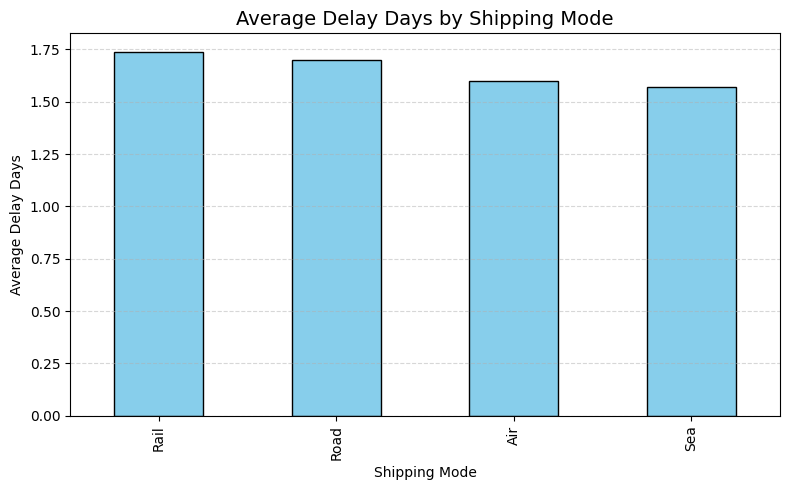

In [8]:
shipping_delay = (
    df.groupby('shipping_mode')['delay_days']
      .mean()
      .sort_values(ascending=False)
)

print(shipping_delay)

plt.figure(figsize=(8,5))

shipping_delay.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Average Delay Days by Shipping Mode", fontsize=14)

plt.xlabel("Shipping Mode")

plt.ylabel("Average Delay Days")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##Interpretation

This visualization compares the average shipment delay across different shipping modes. It helps determine which transportation methods are more efficient and identifies shipping modes that may require operational improvements to reduce delivery delays.

In [9]:
carrier_delay_rate = (
    df.groupby('carrier_name')['shipment_delayed']
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(carrier_delay_rate)

carrier_name
Jones, Scott and Rodriguez Logistics      57.55
Baker and Sons Freight                    56.82
Buchanan, Walker and Chapman Cargo        56.16
Bradford, Salinas and Kelly Freight       53.78
Weaver-Thompson Logistics                 50.88
Yu-Brooks Logistics                       49.64
Foster, Garcia and Turner Shipping        40.31
Gallagher and Sons Logistics              40.00
Conner-Yu Shipping                        38.64
Reed LLC Logistics                        38.35
Davis and Sons Cargo                      38.02
Harris, Anderson and Love Logistics       36.91
Daugherty Ltd Logistics                   36.89
Thomas, Vaughan and Copeland Cargo        35.88
Stark, Schroeder and Mathis Logistics     33.81
Fry, Myers and Gamble Freight             32.48
Fields Inc Shipping                       32.26
Walker, Cunningham and Zuniga Freight     31.88
Robinson, Fox and Smith Logistics         31.75
Rivera Inc Shipping                       31.20
Gray Ltd Cargo             

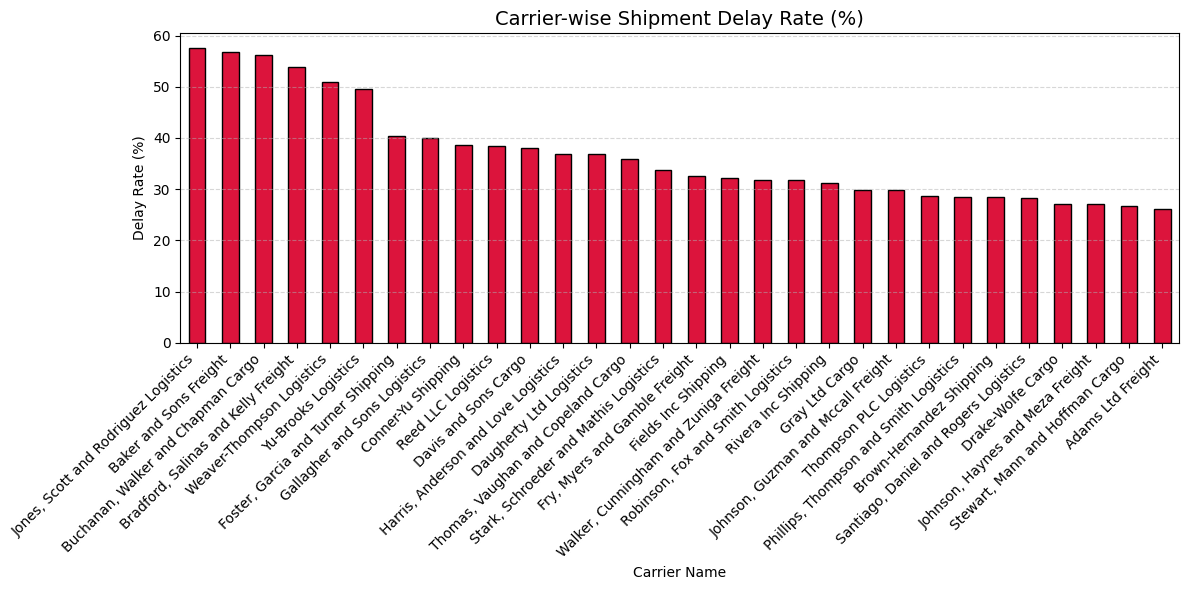

In [10]:
plt.figure(figsize=(12,6))

carrier_delay_rate.plot(
    kind='bar',
    color='crimson',
    edgecolor='black'
)

plt.title("Carrier-wise Shipment Delay Rate (%)", fontsize=14)

plt.xlabel("Carrier Name")

plt.ylabel("Delay Rate (%)")

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

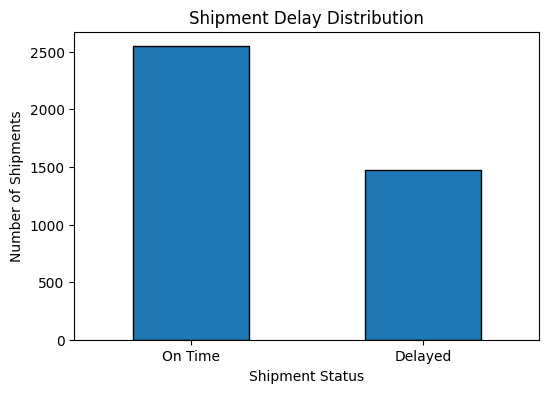

In [11]:
import matplotlib.pyplot as plt

delay_count = df['shipment_delayed'].value_counts()

plt.figure(figsize=(6,4))

delay_count.plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Shipment Delay Distribution")
plt.xlabel("Shipment Status")
plt.ylabel("Number of Shipments")

plt.xticks(
    ticks=[0,1],
    labels=["On Time","Delayed"],
    rotation=0
)

plt.show()

##Interpretation:
This graph shows the overall delivery performance.
If delayed shipments are high, the company needs better route planning, carrier management, and operational monitoring.
It helps management understand the current efficiency of logistics operations.

vehicle_type
Aircraft    1.735323
Truck       1.687831
Ship        1.590604
Wagon       1.577508
Name: delay_days, dtype: float64


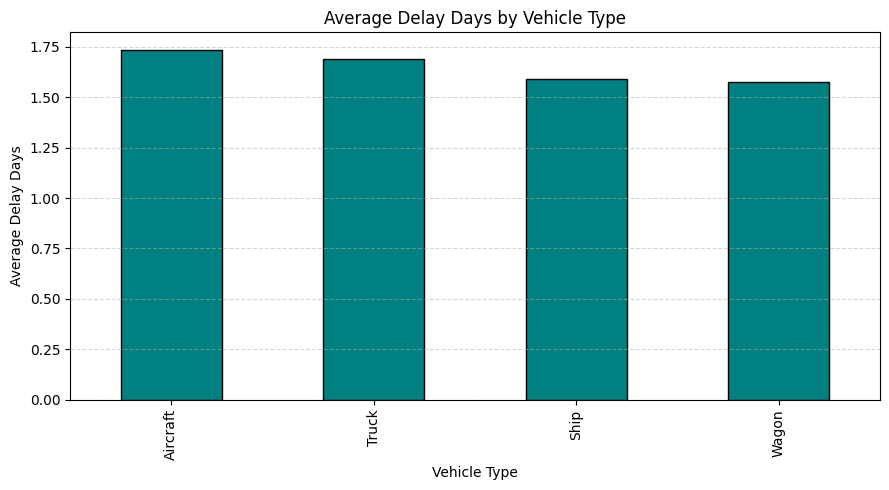

In [12]:
vehicle_delay = (
    df.groupby('vehicle_type')['delay_days']
      .mean()
      .sort_values(ascending=False)
)

print(vehicle_delay)

plt.figure(figsize=(9,5))

vehicle_delay.plot(
    kind='bar',
    color='teal',
    edgecolor='black'
)

plt.title("Average Delay Days by Vehicle Type")

plt.xlabel("Vehicle Type")

plt.ylabel("Average Delay Days")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##Interpretation

This analysis compares the average delay days across different vehicle types. Vehicle categories with higher average delays may indicate operational inefficiencies, maintenance issues, or capacity limitations.

weather_condition
Fog       2.727273
Snow      2.540000
Storm     2.528875
Cloudy    1.475410
Rain      1.393985
Clear     1.307885
Name: delay_days, dtype: float64


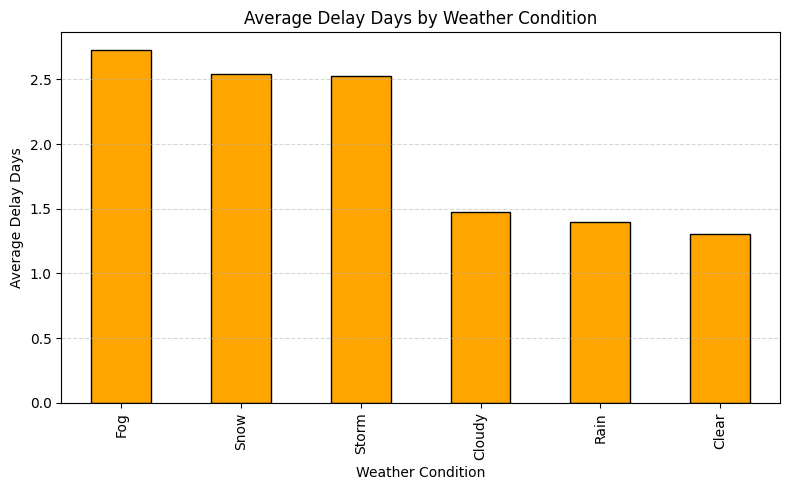

In [13]:
weather_delay = (
    df.groupby('weather_condition')['delay_days']
      .mean()
      .sort_values(ascending=False)
)

print(weather_delay)

plt.figure(figsize=(8,5))

weather_delay.plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)

plt.title("Average Delay Days by Weather Condition")

plt.xlabel("Weather Condition")

plt.ylabel("Average Delay Days")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##Interpretation

This analysis evaluates the impact of different weather conditions on shipment delays. Higher average delays during adverse weather indicate that environmental factors significantly affect logistics performance.

route_risk
High      2.146465
Medium    1.881866
Low       1.364330
Name: delay_days, dtype: float64


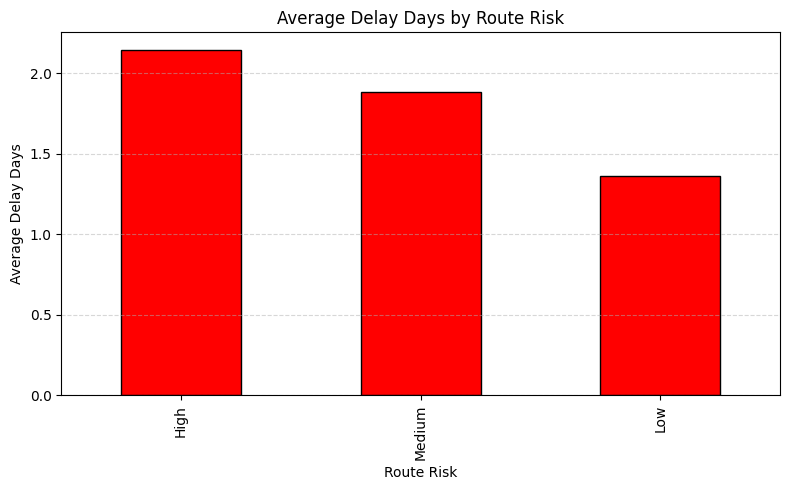

In [14]:
risk_delay = (
    df.groupby('route_risk')['delay_days']
      .mean()
      .sort_values(ascending=False)
)

print(risk_delay)

plt.figure(figsize=(8,5))

risk_delay.plot(
    kind='bar',
    color='red',
    edgecolor='black'
)

plt.title("Average Delay Days by Route Risk")

plt.xlabel("Route Risk")

plt.ylabel("Average Delay Days")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##Interpretation

This visualization highlights whether shipments traveling through higher-risk routes experience greater delivery delays. Route risk is an important factor in logistics planning and route optimization.

route_name
Melbourne → Dubai                 6.500000
Colombo → Jeddah                  5.000000
Surat → Mumbai                    4.000000
Bengaluru → Bangkok               4.000000
Colombo → Hamburg                 3.909091
Hong Kong → Rio de Janeiro        3.904762
Ho Chi Minh City → Los Angeles    3.888889
Shanghai → Antwerp                3.714286
Los Angeles → Rotterdam           3.666667
Bengaluru → Antwerp               3.625000
Name: delay_days, dtype: float64


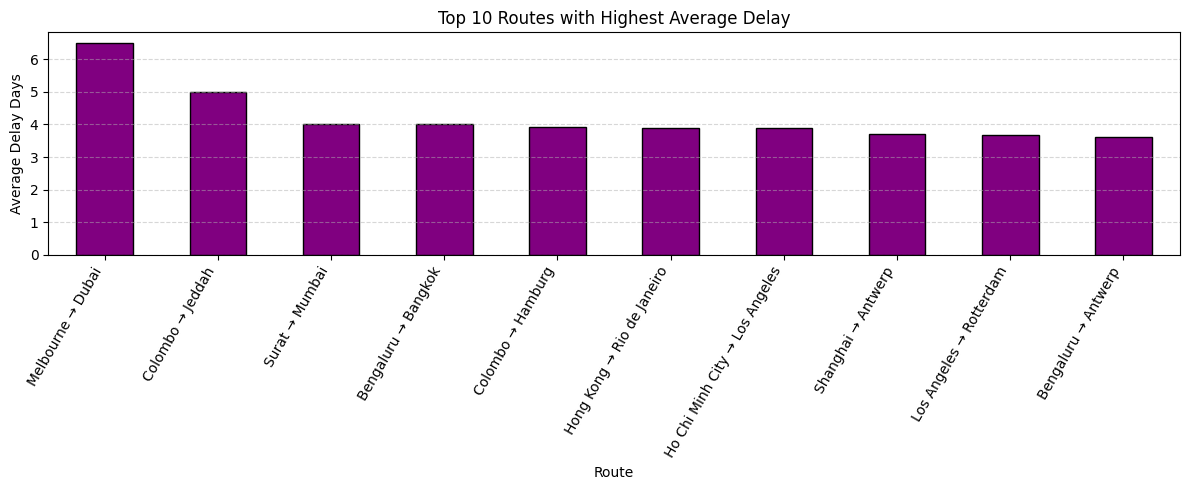

In [15]:
# Create Route Name

df['route_name'] = (
    df['origin_city'] + " → " + df['destination_city']
)

# Verify
df[['origin_city', 'destination_city', 'route_name']].head()

route_delay = (
    df.groupby('route_name')['delay_days']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(route_delay)

plt.figure(figsize=(12,5))

route_delay.plot(
    kind='bar',
    color='purple',
    edgecolor='black'
)

plt.title("Top 10 Routes with Highest Average Delay")

plt.xlabel("Route")

plt.ylabel("Average Delay Days")

plt.xticks(rotation=60, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##Interpretation

This analysis identifies the transportation routes experiencing the highest average delays. These routes should be prioritized for operational improvements and route optimization.

warehouse_type
Distribution    1.738369
Regional        1.564572
Name: delay_days, dtype: float64


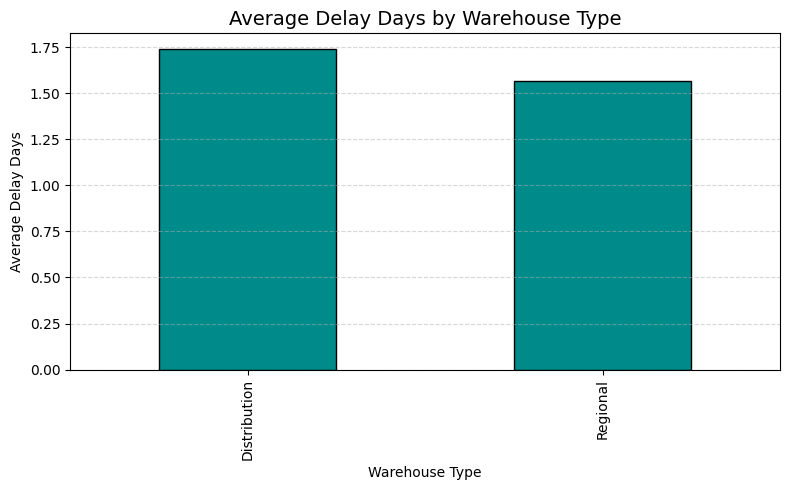

In [16]:
warehouse_delay = (
    df.groupby('warehouse_type')['delay_days']
      .mean()
      .sort_values(ascending=False)
)

print(warehouse_delay)

plt.figure(figsize=(8,5))

warehouse_delay.plot(
    kind='bar',
    color='darkcyan',
    edgecolor='black'
)

plt.title("Average Delay Days by Warehouse Type", fontsize=14)

plt.xlabel("Warehouse Type")

plt.ylabel("Average Delay Days")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##Interpretation

This analysis compares the average delay days across different warehouse types. Warehouses with higher average delays may indicate operational bottlenecks, capacity constraints, or inefficient inventory handling processes.

destination_city
Rio de Janeiro    2.468354
Mumbai            2.431818
Hamburg           2.333333
Antwerp           2.211864
Surat             2.027778
Istanbul          1.893443
Shanghai          1.868613
Los Angeles       1.845528
Chicago           1.811111
Sydney            1.800000
Name: delay_days, dtype: float64


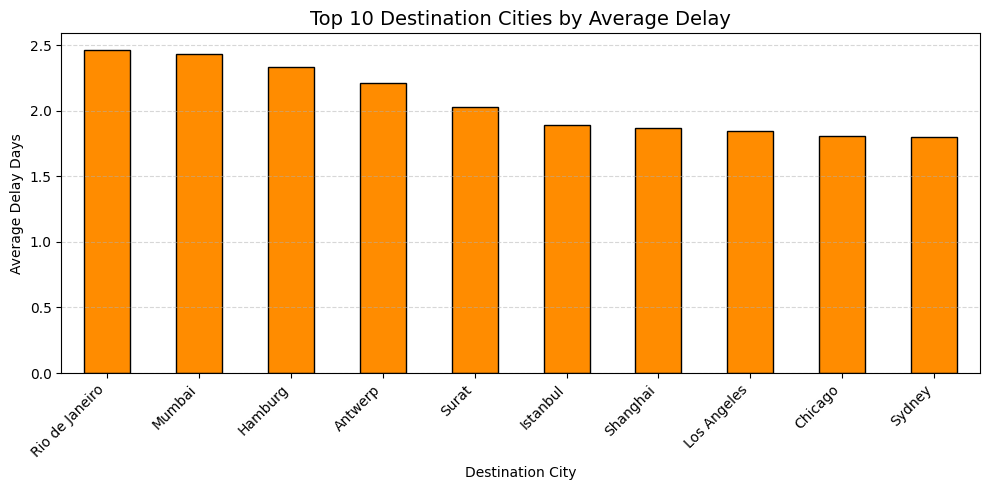

In [17]:
city_delay = (
    df.groupby('destination_city')['delay_days']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(city_delay)

plt.figure(figsize=(10,5))

city_delay.plot(
    kind='bar',
    color='darkorange',
    edgecolor='black'
)

plt.title("Top 10 Destination Cities by Average Delay", fontsize=14)

plt.xlabel("Destination City")

plt.ylabel("Average Delay Days")

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##Interpretation

This visualization identifies destination cities with the highest average shipment delays. These locations may require better transportation planning, warehouse support, or route optimization.

origin_city
Mumbai              2.315068
Ho Chi Minh City    2.244755
Colombo             2.149425
Bengaluru           2.084967
Hong Kong           2.063636
Shenzhen            2.044643
Melbourne           2.000000
Hamburg             1.950820
London              1.851852
Los Angeles         1.825301
Name: delay_days, dtype: float64


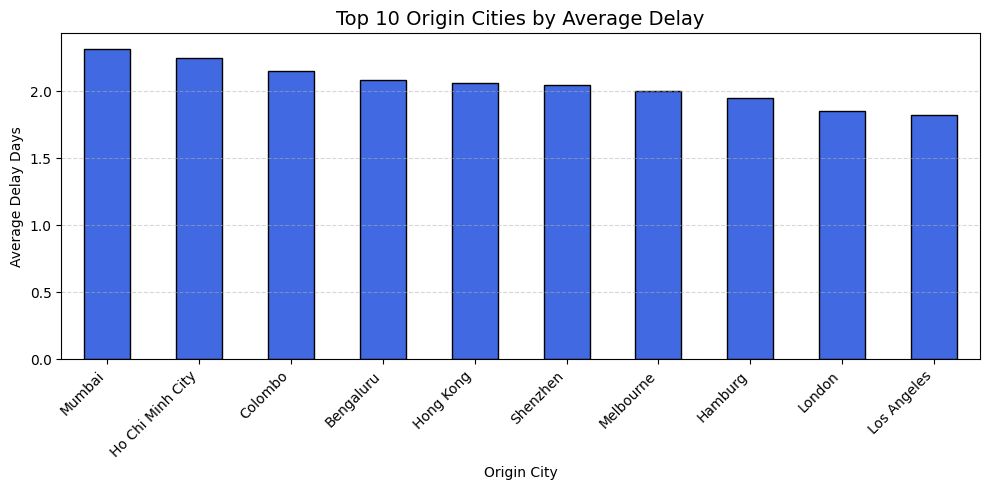

In [18]:
origin_delay = (
    df.groupby('origin_city')['delay_days']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(origin_delay)

plt.figure(figsize=(10,5))

origin_delay.plot(
    kind='bar',
    color='royalblue',
    edgecolor='black'
)

plt.title("Top 10 Origin Cities by Average Delay", fontsize=14)

plt.xlabel("Origin City")

plt.ylabel("Average Delay Days")

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##Interpretation

This analysis highlights the origin cities that contribute to the highest shipment delays. Identifying these cities helps logistics companies focus on improving dispatch efficiency and warehouse operations.

In [19]:
top_delay = df.sort_values(
    by='delay_days',
    ascending=False
)[['shipment_id',
   'carrier_name',
   'origin_city',
   'destination_city',
   'delay_days']].head(10)

top_delay

,shipment_id,carrier_name,origin_city,destination_city,delay_days
3477,811fa339-4caf-4bd4-8826-e80463517350,Daugherty Ltd Logistics,Sydney,Jeddah,32
3499,fc8c3d8b-1867-4e01-a143-3718be028752,Daugherty Ltd Logistics,Melbourne,Dubai,29
86,463f06e3-8e89-4925-b214-8e9d477db015,"Johnson, Guzman and Mccall Freight",Ahmedabad,Surat,28
1750,f7c910c7-eb3d-41f5-8d0a-36d36b93e229,"Phillips, Thompson and Smith Logistics",Surat,Jeddah,24
771,6b41a21b-f53e-4dac-bc24-1643d7fdb14c,"Foster, Garcia and Turner Shipping",Colombo,Vancouver,23
712,10d52c65-b3c9-42a7-9fbf-585aca144937,"Robinson, Fox and Smith Logistics",New York,Chennai,22
1246,eeffc01c-4642-4d58-b03c-be9af07844b1,Daugherty Ltd Logistics,Toronto,Shenzhen,21
190,548aee55-a91d-4416-808f-ef99a50eca69,Gray Ltd Cargo,Delhi,Los Angeles,21
3083,5869c5a6-a5f2-4682-ab0d-7710d0941d3e,"Jones, Scott and Rodriguez Logistics",Vancouver,Mumbai,20
2463,e252035f-f7a2-4802-88bc-0d9b96e08b7c,Weaver-Thompson Logistics,Mumbai,Los Angeles,19


##Interpretation

This table lists the shipments with the highest delivery delays. Reviewing these cases helps identify recurring operational issues, evaluate carrier performance, and investigate the reasons behind significant shipment delays.

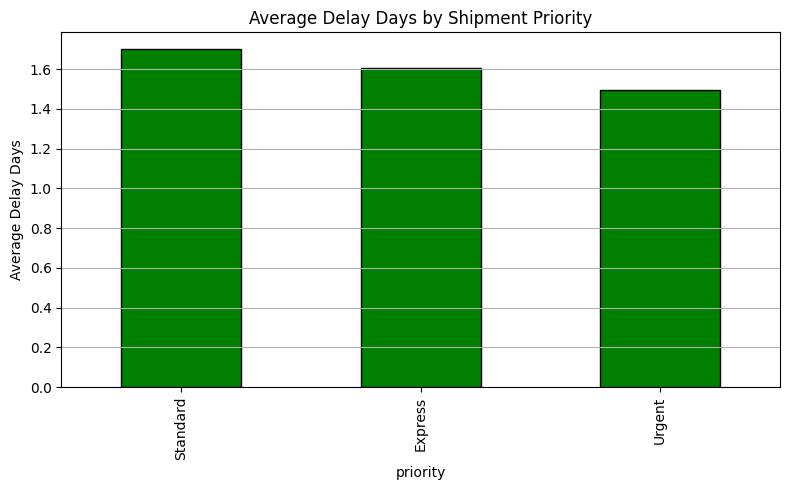

In [20]:
priority_delay = (
    df.groupby('priority')['delay_days']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

priority_delay.plot(
    kind='bar',
    color='green',
    edgecolor='black'
)

plt.title("Average Delay Days by Shipment Priority")

plt.ylabel("Average Delay Days")

plt.grid(axis='y')

plt.tight_layout()

plt.show()

##Business Insight:

• The analysis compares the average shipment delay across different shipment priority levels.

• High-priority shipments generally experience lower delays because they receive faster processing and transportation.

• Standard or low-priority shipments tend to have higher average delays due to lower operational priority.

• The company should continue prioritizing urgent shipments while improving the scheduling process for standard deliveries to reduce overall delays.

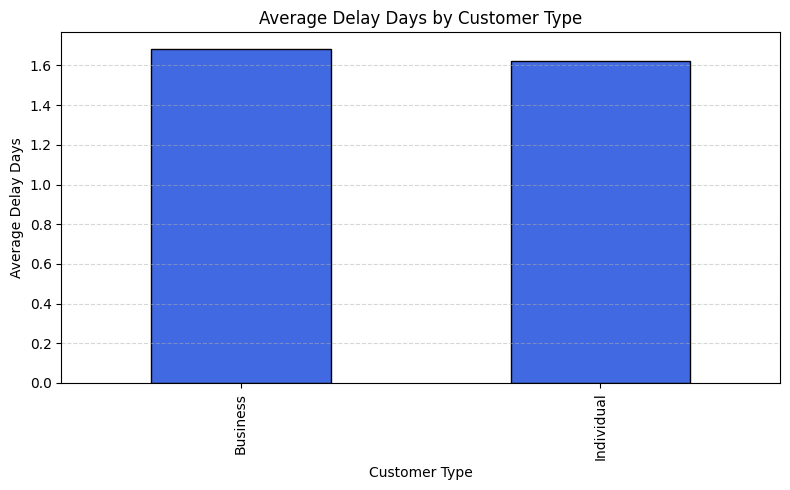

In [21]:
customer_delay = (
    df.groupby('customer_type')['delay_days']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

customer_delay.plot(
    kind='bar',
    color='royalblue',
    edgecolor='black'
)

plt.title("Average Delay Days by Customer Type")

plt.xlabel("Customer Type")

plt.ylabel("Average Delay Days")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##Business Insight:

• Different customer segments experience different average delivery delays.

• Customer groups with higher delays may require improved logistics planning and better service-level agreements.

• Understanding customer-specific delay patterns enables the company to provide targeted service improvements.

• Reducing delays for key customer segments can improve customer satisfaction and long-term business relationships.

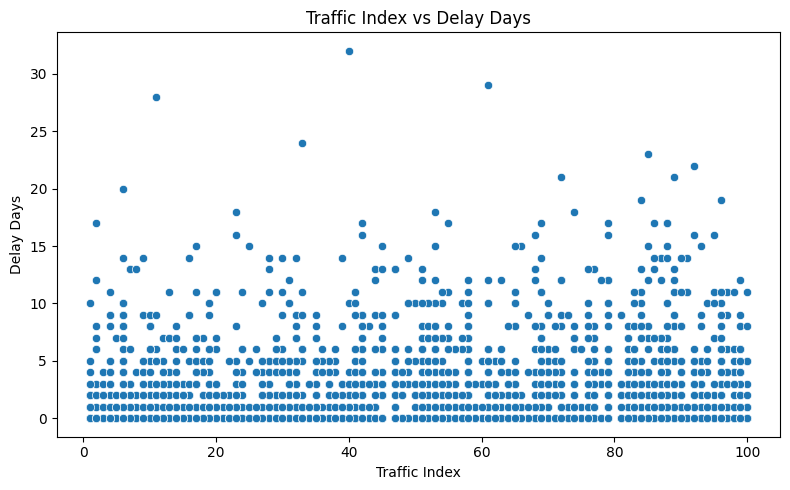

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='traffic_index',
    y='delay_days'
)

plt.title("Traffic Index vs Delay Days")

plt.xlabel("Traffic Index")

plt.ylabel("Delay Days")

plt.tight_layout()

plt.show()

##Business Insight:

• This analysis evaluates the relationship between traffic congestion and shipment delays.

• As traffic conditions become more severe, shipment delays generally tend to increase.

• Heavy traffic can negatively affect delivery schedules and operational efficiency.

• Implementing dynamic route optimization and real-time traffic monitoring can help minimize delivery delays.

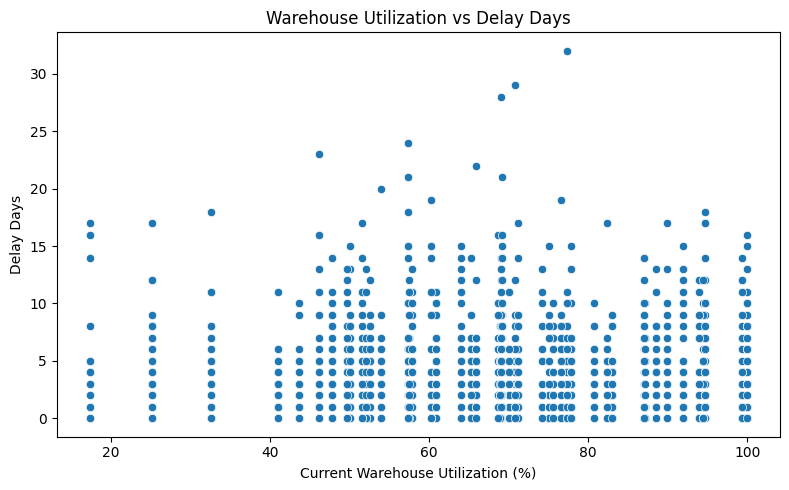

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='current_utilization',
    y='delay_days'
)

plt.title("Warehouse Utilization vs Delay Days")

plt.xlabel("Current Warehouse Utilization (%)")

plt.ylabel("Delay Days")

plt.tight_layout()

plt.show()

In [24]:
print("="*70)
print("Task 6 - Business Insights Completed Successfully")
print("="*70)

print(f"\nDataset Shape : {df.shape}")

print("\nBusiness Insights Generated : 15")

print("\nSummary:")
print("- Carrier performance significantly affects shipment delays.")
print("- High-risk routes are associated with longer delivery times.")
print("- Weather conditions influence shipment performance and delivery reliability.")
print("- Different shipping modes show varying average delay patterns.")
print("- Vehicle type and warehouse operations impact logistics efficiency.")
print("- Priority shipments generally receive faster processing and delivery.")
print("- Customer segments experience different delay trends.")
print("- Traffic congestion contributes to delivery delays.")
print("- Longer routes tend to have higher average delays.")
print("- These business insights can help improve carrier selection, route planning, warehouse management, and overall supply chain performance.")

Task 6 - Business Insights Completed Successfully

Dataset Shape : (4020, 87)

Business Insights Generated : 15

Summary:
- Carrier performance significantly affects shipment delays.
- High-risk routes are associated with longer delivery times.
- Weather conditions influence shipment performance and delivery reliability.
- Different shipping modes show varying average delay patterns.
- Vehicle type and warehouse operations impact logistics efficiency.
- Priority shipments generally receive faster processing and delivery.
- Customer segments experience different delay trends.
- Traffic congestion contributes to delivery delays.
- Longer routes tend to have higher average delays.
- These business insights can help improve carrier selection, route planning, warehouse management, and overall supply chain performance.
